# Performance of big data problems II

[Matt Graham](https://matt-graham.github.io)
[](https://orcid.org/0000-0001-9104-7960)
(Centre for Advanced Research Computing)  
[Anastasis
Georgoulas](https://uk.linkedin.com/in/anastasis-georgoulas-265b12167)
[](https://orcid.org/0000-0001-7187-5443)

## Introduction

This lecture will talk about three open-source frameworks for **large
scale data processing**:

-   Apache Hadoop,
-   Apache Spark,
-   Dask.

All three allow users to take advantage of **distributed architectures
for data processing**.

## Learning outcomes

-   Describe the key features of Hadoop, Spark and Dask.
-   Recognize the advantages of using distributed file systems for data
    processing.
-   Use `pyspark` to programmatically access Spark’s capabilities.
-   Explain why we would want to perform stream data processing.
-   Compare Spark and Dask’s differences and similarities.

## Hadoop

Hadoop is a framework with several components.

We will focus on two of them:

-   The **Hadoop Distributed File System (HDFS)**.
-   An implementation of **MapReduce**.

Together, these two elements let users **distribute data processing**
across many nodes without having to worry (too much) about how files are
structured or how computation is performed.

## Distributed file systems

Distributed file systems store files across **many storage nodes**.

Instead of a single copy, each file resides in **multiple copies**
across **different parts** of the system.

-   **Data locality** - processing tasks can locally access data they
    need.
-   **Consistency** ensured through synchronization.
-   **Scalable** by adding more nodes.
-   **Resistant** to failure.
-   **Transparency** - the user should not need to know the details of
    how the file system works.

## Hadoop MapReduce

To write a MapReduce application in Hadoop, a user must:

-   Specify the *mapper* (how should a small chunk of data be
    processed?).
-   Specify the *reducer* (how should the mapper results be combined?).
-   Get the data onto HDFS (the cluster nodes).
-   Launch the job by pointing to the data, mapper and reducer.

Hadoop is Java based but it is possible to specify the mapper and
reducer in other languages using the [Hadoop
Streaming](https://hadoop.apache.org/docs/r1.2.1/streaming.html)
interface - for example [in
Python](https://www.michael-noll.com/tutorials/writing-an-hadoop-mapreduce-program-in-python/).

Once these components are specified and a job is launched, Hadoop takes
care of the rest, including the communication between the different
stages and determining on which nodes processing occurs.

This can be powerful for **handling large volumes** of data relatively
**simply**.

While powerful, Hadoop MapReduce is mainly appropriate for large **batch
processing** tasks.

## Hadoop MapReduce data flow

The MapReduce model enforces a linear data flow structure:

-   data chunks are read from disk in the HDFS,
-   the mapper processes the data chunks,
-   the reducer combines the mapper outputs,
-   the results are written back to disk in the HDFS.

This restriction makes Hadoop MapReduce **less efficient** for
**iterative algorithms** and **interactive data exploration**, due to
the **high overhead** of repeatedly reading and writing to disk.

## Spark

Apache Spark is a framework for processing large amounts of data **in
memory**.

It supports more general workflows than Hadoop MapReduce, and by
**avoiding writing to disk** unless needed, allows more efficient
**iteration** and **data exploration**.

It can run **on top of Hadoop** and take advantage of HDFS.

## Spark features

Basic features of Spark:

-   **Lazy**: does not perform computations until required.
-   **In-memory processing**: faster than using disk storage.
-   **Resilience**: steps used to produce data tracked to allow
    reconstruction.
-   **Streams**: can handle data in real time as it arrives (“online”).

## Spark SQL and datasets

Spark comes with interfaces in a few languages, including Python
([`pyspark`](https://spark.apache.org/docs/latest/api/python/getting_started/index.html)).

These offer **programmatic access** to its various capabilities.

**Spark SQL** is a component for **structured data processing** with
support for **executing SQL queries**.

The key abstractions in Spark SQL are `Dataset`s and `DataFrame`s -
`pyspark` only supports `DataFrame`s.

These both represent collections of items that may be **distributed over
multiple nodes**.

## Example: `pyspark` pandas

`DataFrame`s can be created by specifying the values directly, or by
reading from and transforming an existing source (including a Pandas
`DataFrame`).

In [1]:
import warnings
# Ignore FutureWarning as installed Pyspark version uses deprecated method
warnings.simplefilter(action='ignore')

In [2]:
import pyspark.pandas as ps

dataframe = ps.DataFrame({"x": [1, 2.1, 3.5],  "y": [2, 4.2, 7]})
dataframe

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/12 21:37:05 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
[Stage 0:>                                                          (0 + 1) / 1]                                                                                

Spark `DataFrame`s can also be handled like pandas `DataFrame`s:

In [3]:
dataframe["z"] = dataframe["x"] * dataframe["y"]
dataframe

This allows using Spark’s distributed processing functionality without
major changes from code that originally used pandas.

The distributed nature of the data is **transparent**.

## MLlib

Spark includes an extensive *Machine Learning library*
([`MLlib`](https://spark.apache.org/docs/latest/ml-guide.html)), with
support for

-   classification,
-   regression,
-   clustering,
-   reading from different file types,
-   data pipelines.

Using Spark’s `MLlib` allows taking advantage of distributed processing
more easily than for example `scikit-learn`.

## Example: `MLlib` logistic regression

To allow us to demonstrate fitting a logistic regression model with
`MLlib`, we first download an example data file and save it in a local
temporary file:

In [4]:
import urllib.request
import tempfile

response = urllib.request.urlopen(
    "https://raw.githubusercontent.com/apache/spark/"
    "master/data/mllib/sample_libsvm_data.txt"
)
data_temp_file = tempfile.NamedTemporaryFile()
with open(data_temp_file.name, "wb") as f:
    contents = response.read()
    f.write(contents)

We now train a logistic regression model and print the fitted parameters
([adapted from the Spark
documentation](https://github.com/apache/spark)):

In [5]:
from pyspark.sql import SparkSession
from pyspark.ml.classification import LogisticRegression

spark = SparkSession.builder.getOrCreate()
data = spark.read.format("libsvm").load(data_temp_file.name , numFeatures=692)
model = LogisticRegression(maxIter=10, regParam=0.3, elasticNetParam=0.8)
model = model.fit(data)
print(f"Coefficients = {repr(model.coefficients)}\n")
print(f"Intercept = {model.intercept}")

Coefficients = SparseVector(692, {272: -0.0001, 300: -0.0001, 323: 0.0, 350: 0.0004, 351: 0.0003, 378: 0.0006, 379: 0.0004, 405: 0.0004, 406: 0.0008, 407: 0.0005, 428: -0.0, 433: 0.0006, 434: 0.0009, 435: 0.0001, 455: -0.0, 456: -0.0, 461: 0.0005, 462: 0.0008, 483: -0.0001, 484: -0.0, 489: 0.0005, 490: 0.0005, 496: -0.0, 511: -0.0003, 512: -0.0001, 517: 0.0005, 539: -0.0001, 540: -0.0004, 568: -0.0001})

Intercept = -0.5991460286401438

## Spark Streaming

In many cases, it is not possible to access all the data at once, due to
size or availability.

[Spark
Streaming](https://spark.apache.org/docs/latest/streaming-programming-guide.html)
allows processing data points **as they arrive**.

<figure>
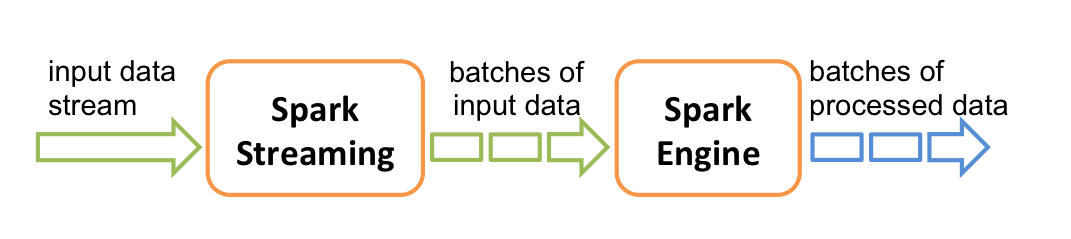
<figcaption aria-hidden="true">Image Credit: Apache Spark
documentation</figcaption>
</figure>

It does this by creating small **batches** of data, calculating
**processed results**, and updating those as more data arrives.

-   Can incorporate **real-time data**.
-   Can be more efficient when loading **large datasets** or from
    sources with **high latency**.
-   Algorithm and program structure may need to be **adapted**, but
    Spark provides features for “hiding” that.
-   MLlib contains implementations for fitting on streaming training
    data, or making predictions on streaming test data.

## Dask

[Dask](https://docs.dask.org/en/stable/) is *a Python library for
parallel and distributing computing*.

Dask [shares similarities with Apache
Spark](https://docs.dask.org/en/stable/spark.html) in using a *lazy
evaluation* model, providing a [pandas-like `DataFrame`
interface](https://docs.dask.org/en/stable/dataframe.html) and
supporting [streaming
computation](https://docs.dask.org/en/stable/spark.html#streaming).

Unlike Spark, Dask is written in and **primarily used within Python**,
and is **tightly integrated** with other packages in the wider Python
ecosystem.

Dask does not support SQL but equivalent operation can be performed
using its Python interface.

## Dask task scheduling

Dask supports a generic **task-scheduling** paradigm that can make it
more flexible than alternatives such as Spark

<figure>

<figcaption aria-hidden="true">Image credit: Dask
documentation</figcaption>
</figure>

A **graph** of the tasks corresponding to a computation is built and can
be then be executed on a variety of **schedulers** working on both
single-machines and clusters.

## Example: Dask timeseries analysis

As a simple example, we construct a simulated timeseries `DataFrame` in
Dask using the [`dask.dataset.timeseries`
function](https://docs.dask.org/en/stable/api.html#dask.datasets.timeseries)

In [6]:
import dask

dataframe = dask.datasets.timeseries(
  start="2000-01-01", end="2000-01-29", seed=1234, partition_freq="7d"
)

The generated `DataFrame` here is relatively large:

In [7]:
print("Number of records: ", dataframe.size.compute())

Number of records:  9676800

Importantly Dask data structures are *partitioned* to allow distributing
computations on chunks of the data.

In [8]:
dataframe

Dask Name: to_string_dtype, 2 expressions

As with pandas `DataFrame` objects we can use the `head` method to
inspect the first few rows

In [9]:
dataframe.head()

Dask `DataFrame`s provide a pandas like interface which we can use to
perform filtering, grouping and aggregation operations.

In [10]:
filtered = dataframe[dataframe.x > 0]
grouped = filtered.groupby("name")
results = grouped["x", "y"].std()
results

Dask Name: std, 7 expressions

Unlike pandas where operations are evaluated *eagerly*, operations in
Dask are evaluated *lazily* with an expression graph being built
representing the applied operations.

We can visualize the *expression graph* associated with a Dask
`DataFrame` using the `visualize` method

In [11]:
results.visualize(rankdir="TD")

We can also *optimize* the expression graph, for example fusing
operations

In [12]:
optimized = results.optimize()
optimized.visualize(rankdir="TD")

We can also instead visualize the constructed *task graph*

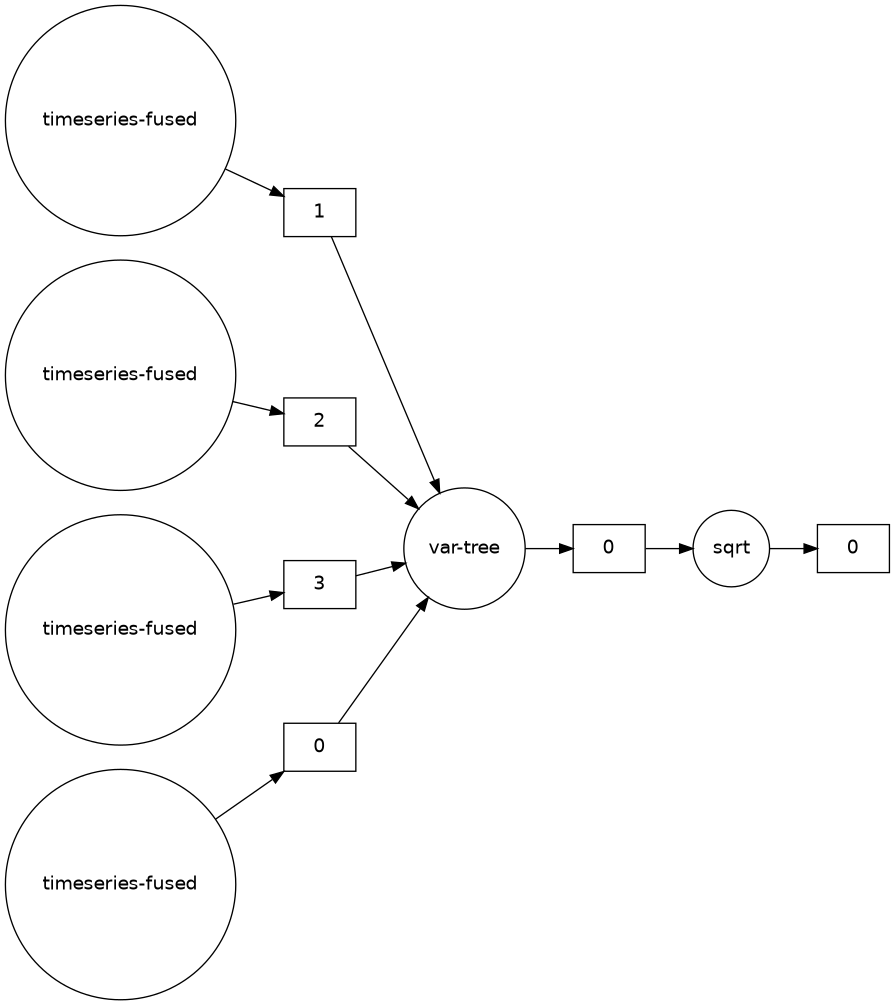

In [13]:
optimized.visualize(tasks=True, rankdir="LR")

Calling the `compute` method on a Dask `DataFrame` will *schedule* the
attached task graph, and output a pandas `DataFrame`

In [14]:
optimized.compute().head()

Dask defaults to a **threaded scheduler** to run computations, but
**distributed schedulers** can be used instead.

## Summary

-   Using frameworks makes it much easier to build applications with
    distributed data processing.
-   Hadoop and Spark are complementary: Hadoop provides more basic
    functionality, while Spark can run standalone and is better for data
    that fits in memory.
-   Dask is a modern Python based alternative to Spark for distributed
    data processing that offers a very general task scheduling
    framework.